In [ ]:
import cProfile
import pstats
import sys
from pathlib import Path
from pstats import SortKey

import numpy as np
import pandas as pd
from river.decomposition import OnlineDMDwC
from river.preprocessing import Hankelizer
from tqdm import tqdm

sys.path.append("../")

from functions.chdsubid import (
    SubIDChangeDetector,
    get_default_rank,
)
from functions.datasets import load_cats
from functions.metrics import chp_score
from functions.plot import plot_chd
from functions.preprocessing import hankel
from functions.rolling import Rolling

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Read data
df = load_cats(resample_s=60)
df.index = pd.to_datetime(df.index)
U = df[["aimp", "amud", "adbr", "adfl"]]
X = df[
    [
        "bed1",
        "bed2",
        "bfo1",
        "bfo2",
        "bso1",
        "bso2",
        "bso3",
        "ced1",
        "cfo1",
        "cso1",
    ]
]
Y_true = df.pop("y")
Y_cat = df.pop("category")

In [ ]:
window_size: int = 60 * 24
# Base size
ref_size = 60 * 5
test_size = 60 * 5
# If window_size is not very large, then take half
h_max = int(60 / X.shape[1])
h_reco = 60 * 4
if h_reco < h_max:
    hn = h_reco
    hu = h_reco
    step = 1
else:
    hn = h_max
    hu = h_max
    step = (h_reco) // h_max
# Optimal low-rank representation of signal with unknown noise variance
p = min(len(X.columns), get_default_rank(hankel(X[:window_size], hn, step)))
print(f"Optimal rank for states is: {p}")
q = min(len(U.columns), get_default_rank(hankel(U[:window_size], hu, step)))
print(f"Optimal rank for inputs is: {q}")

Snapshots processed:   0%|          | 0/83274 [00:00<?, ?it/s]

Snapshots processed:   2%|▏         | 1996/83274 [00:01<00:40, 1990.27it/s]

Snapshots processed:   5%|▍         | 3987/83274 [00:07<02:54, 454.30it/s] 

Snapshots processed:   6%|▌         | 4980/83274 [00:10<03:13, 404.01it/s]

Snapshots processed:   7%|▋         | 5666/83274 [00:13<03:29, 369.94it/s]

...

Snapshots processed:  99%|█████████▉| 82759/83274 [33:30<08:26,  1.02it/s]

Snapshots processed: 100%|█████████▉| 83122/83274 [33:31<01:37,  1.55it/s]

Snapshots processed: 100%|██████████| 83274/83274 [33:32<00:00, 41.38it/s]

/Users/mw/pyprojects/phd/researcher/odmd-subid-cpd/.venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


/Users/mw/pyprojects/phd/researcher/odmd-subid-cpd/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


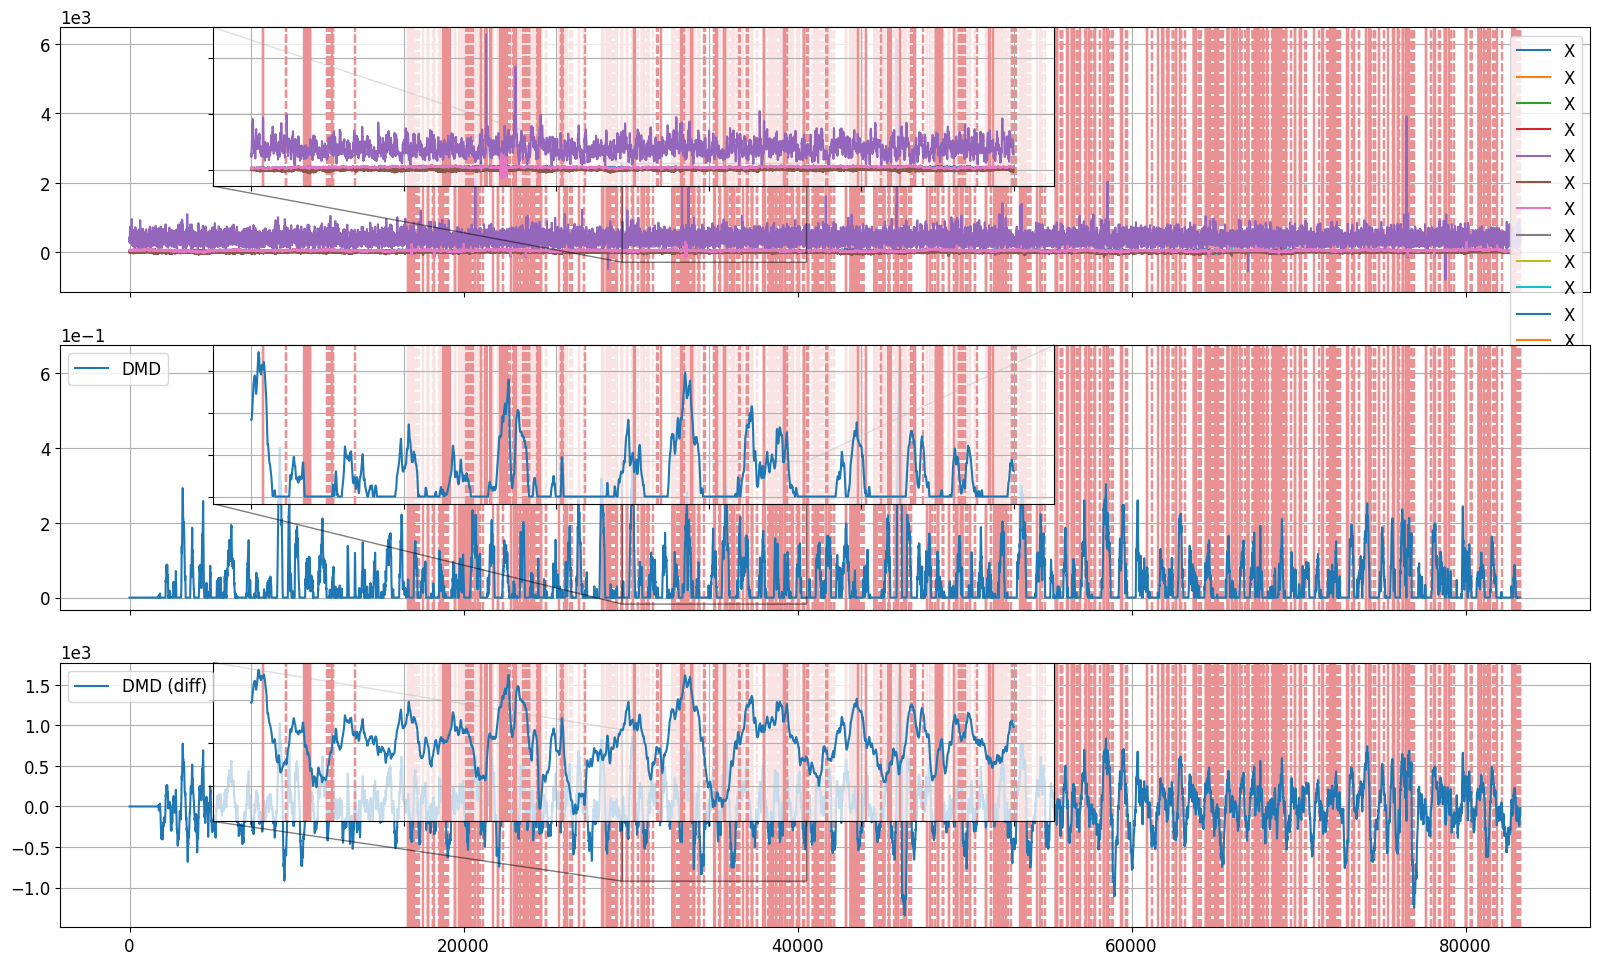

In [ ]:
# [donotremove]
# TODO(MarekWadinger): enable hankelization of us on the fly (#8)
U_ = pd.DataFrame(hankel(U, hn=hu))

# Initialize Hankelizer
hankelizer = Hankelizer(hn)

# Initialize Transformer
init_size = window_size
odmd = Rolling(
    OnlineDMDwC(
        p=p,
        q=q,
        initialize=init_size,
        w=1.0,
        exponential_weighting=False,
        eig_rtol=1e-1,
    ),
    init_size + 1,
)

# Initialize Change-Point Detector
subid_dmd = SubIDChangeDetector(
    odmd,
    ref_size=ref_size,
    test_size=test_size,
    grace_period=init_size + test_size + 1,
)

# Build pipeline
pipeline_dmd = hankelizer | subid_dmd

# Prepare arrays for storing results
scores_dmd = np.zeros(X.shape[0], dtype=float)
# scores_svd = np.zeros(X.shape[0], dtype=float)
scores_dmd_diff = np.zeros(X.shape[0], dtype=complex)
dist = np.zeros((X.shape[0], 2), dtype=complex)
modes = np.empty((X.shape[0], hn * X.shape[1], p), dtype=complex)

# Run pipeline
for i, (x, u) in tqdm(
    enumerate(
        zip(
            X.to_dict(orient="records"),
            U_.to_dict(orient="records"),
            strict=False,
        ),
    ),
    total=len(X),
    mininterval=1.0,
    desc="Snapshots processed",
):
    scores_dmd[i] = pipeline_dmd.score_one(x)
    dist[i, :] = subid_dmd.distances
    scores_dmd_diff[i] = dist[i, 1] - dist[i, 0]

    pipeline_dmd.learn_one(x, u=u)

# Plot results
X_ = df.to_numpy()
Y_ = Y_true.to_numpy()
fig, axs = plot_chd(
    [X_, scores_dmd.real, scores_dmd_diff.real],
    np.where(Y_ == 1)[0],
    labels=["X", "DMD", "DMD (diff)", "SVD"],
    ids_in_start=[30000],
    ids_in_end=[40000],
    grace_period=test_size,
)
fig_name = (
    f"results/.cats/cats-chd_p{p}_q{q}-l{init_size}_b{ref_size}_t{test_size}"
    f"{f'roll_{odmd.window_size}' if isinstance(odmd, Rolling) else 'noroll'}-"
    f"dmd_w{odmd.w}-hx{hn}-hu{hu}-imag.pdf"
)
fig.set_size_inches(18, 10)  # Set the size of the figure
Path(fig_name).parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_name)

In [ ]:
pred_shift = 1
y_true = pd.Series(Y_, index=df.index)
y_true_cp = y_true.diff().abs().fillna(0.0)

In [ ]:
experiments: dict[str, pd.Series] = {
    "Perfect detector": y_true,
    "Random detector": pd.Series(
        np.random.randint(2, size=df.shape[0]),
        index=df.index,
    ),
    "Null detector": pd.Series(np.zeros(df.shape[0]), index=df.index),
    "Always positive": pd.Series(np.ones(df.shape[0]), index=df.index),
    "Online DMD (t=0)": pd.Series(scores_dmd > 0.0, index=df.index),
    "Online DMD (t=0.5)": pd.Series(scores_dmd > 0.5, index=df.index),
    "Online DMD": pd.Series(scores_dmd > 0.25, index=df.index),
}

window_params = {
    "valid": {
        "window_width": f"{test_size}min",
        "anomaly_window_destination": "righter",
    },
}

metrics = [
    "F1",
    "FAR",
    "MAR",
    "Delay",
    "TP",
    "FN",
    "FP",
    "Standard",
    "LowFP",
    "LowFN",
]

df_res = pd.DataFrame(
    columns=pd.Index(list(metrics)),
    index=pd.Index(list(experiments.keys())),
)

for name, po in experiments.items():
    pc = po.astype(int).diff().abs().fillna(0.0)
    res = {}
    for kwargs in window_params.values():
        binary = chp_score(
            y_true,
            po,
            metric="binary",
        )
        add = chp_score(
            y_true_cp,
            pc,
            metric="average_time",
            window_width=kwargs["window_width"],
            anomaly_window_destination=kwargs["anomaly_window_destination"],
        )
        nab = chp_score(
            y_true_cp,
            pc,
            metric="nab",
            window_width=kwargs["window_width"],
            anomaly_window_destination=kwargs["anomaly_window_destination"],
        )
        res_ = dict(zip(["F1", "FAR", "MAR"], binary, strict=False))
        res_.update(dict(zip(["Delay", "FN", "FP", "TP"], add, strict=False)))
        res_.update(nab)
        res_ = dict(res_.items())
        res.update(res_)
    df_res.loc[name] = res

df_res

# Time Profiling to Reveal the Main Bottlenecks

In [ ]:
import datetime


def simulate() -> None:
    # Initialize Hankelizer
    U_ = pd.DataFrame(hankel(U, hn=hu))

    # Initialize Hankelizer
    hankelizer = Hankelizer(hn)

    # Initialize Transformer
    init_size = window_size
    odmd = Rolling(
        OnlineDMDwC(
            p=p,
            q=q,
            initialize=init_size,
            w=1.0,
            exponential_weighting=False,
            eig_rtol=1e-1,
        ),
        init_size + 1,
    )

    # Initialize Change-Point Detector
    subid_dmd = SubIDChangeDetector(
        odmd,
        ref_size=ref_size,
        test_size=test_size,
        grace_period=init_size + test_size + 1,
    )

    # Build pipeline
    pipeline_dmd = hankelizer | subid_dmd

    # Prepare arrays for storing results
    scores_dmd = np.zeros(X.shape[0], dtype=float)
    # Run pipeline
    for i, (x, u) in tqdm(
        enumerate(
            zip(
                X.to_dict(orient="records"),
                U_.to_dict(orient="records"),
                strict=False,
            ),
        ),
        total=len(X),
        mininterval=10.0,
        desc="Snapshots processed",
    ):
        scores_dmd[i] = pipeline_dmd.score_one(x)

        pipeline_dmd.learn_one(x, u=u)


cProfile.run(
    "simulate()",
    f".stats_{datetime.datetime.now(datetime.UTC).strftime('%Y-%m-%d_%H%M%S')}",
)

In [ ]:
perf_stats = pstats.Stats(".stats_pd_2024-05-17_225443")
perf_stats.strip_dirs().sort_stats(SortKey.CUMULATIVE).print_stats()

In [ ]:
stats_files = sorted(Path().glob(".stats_2*"))
if stats_files:
    perf_stats = pstats.Stats(str(stats_files[-1]))
    perf_stats.strip_dirs().sort_stats(SortKey.CUMULATIVE).print_stats()
else:
    print(
        "No profiling stats files found. Run the profiling cell above first.",
    )